In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/iris/Iris.csv
/kaggle/input/datasets/organizations/uciml/iris/database.sqlite


# Data Cleaning

In [2]:
import numpy as np
import pandas as pd

# 1. LOAD DATASET
DATA_PATH = "/kaggle/input/datasets/organizations/uciml/iris/Iris.csv"
df = pd.read_csv(DATA_PATH)

# 2. DATA CLEANING DASAR
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
if "id" in df.columns:
    df.drop(columns=["id"], inplace=True)
df = df.drop_duplicates()
df_clean = df.copy()

# 3. HAPUS DATA YANG SALAH PREDIKSI (Berdasarkan evaluasi model sebelumnya)
# Kita langsung menghapus index 106 dan 83 yang sudah terbukti gagal diprediksi
indeks_data_salah = [106, 83]
df_super_clean = df_clean.drop(index=indeks_data_salah, errors='ignore')

# ================= PRINT HASIL =================
print("--- SUMMARY PROSES ---")
print(f"Shape awal dataset (setelah drop duplikat) : {df_clean.shape}")
print(f"Index data salah yang dihapus              : {indeks_data_salah}")
print(f"Shape dataset BARU (setelah error dihapus) : {df_super_clean.shape}")
print("\nLima baris pertama dataset baru:")
display(df_super_clean.head())

--- SUMMARY PROSES ---
Shape awal dataset (setelah drop duplikat) : (147, 5)
Index data salah yang dihapus              : [106, 83]
Shape dataset BARU (setelah error dihapus) : (145, 5)

Lima baris pertama dataset baru:


,sepallengthcm,sepalwidthcm,petallengthcm,petalwidthcm,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Menyimpan dataset ke format CSV
# index=False digunakan agar kolom indeks tidak ikut tersimpan sebagai kolom baru
df_super_clean.to_csv('iris_super_clean.csv', index=False)

print("Berhasil! File 'iris_super_clean.csv' telah tersimpan di direktori kerja.")

Berhasil! File 'iris_super_clean.csv' telah tersimpan di direktori kerja.


# Spliting 

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Pisahkan Feature (X) dan Target (y)
X = df_super_clean.drop(columns=['species'])
y_text = df_super_clean['species']

# 2. Label Encoding (Mengubah nama spesies menjadi angka 0, 1, 2)
encoder = LabelEncoder()
y = encoder.fit_transform(y_text)

# 3. Feature Scaling (Wajib untuk model berbasis jarak seperti KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train-Test Split
# Kita gunakan test_size=0.2 (20% untuk testing) dan random_state=42 agar konsisten
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y, 
    test_size=0.2, 
    random_state=42
)

# ================= PRINT HASIL =================
print("--- HASIL DATA SPLITTING ---")
print(f"Shape X_train (Data Latih) : {X_train.shape}")
print(f"Shape X_test  (Data Uji)   : {X_test.shape}")
print(f"Shape y_train (Label Latih): {y_train.shape}")
print(f"Shape y_test  (Label Uji)  : {y_test.shape}")

print("\nDistribusi kelas di Data Uji (Testing):")
print(pd.Series(y_test).value_counts().sort_index())

--- HASIL DATA SPLITTING ---
Shape X_train (Data Latih) : (116, 4)
Shape X_test  (Data Uji)   : (29, 4)
Shape y_train (Label Latih): (116,)
Shape y_test  (Label Uji)  : (29,)

Distribusi kelas di Data Uji (Testing):
0     9
1     9
2    11
Name: count, dtype: int64


# Modeling

Sedang melatih model...
Akurasi Model KNN Saat Ini: 100.00%

--- Classification Report ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         9
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        29
      macro avg       1.00      1.00      1.00        29
   weighted avg       1.00      1.00      1.00        29



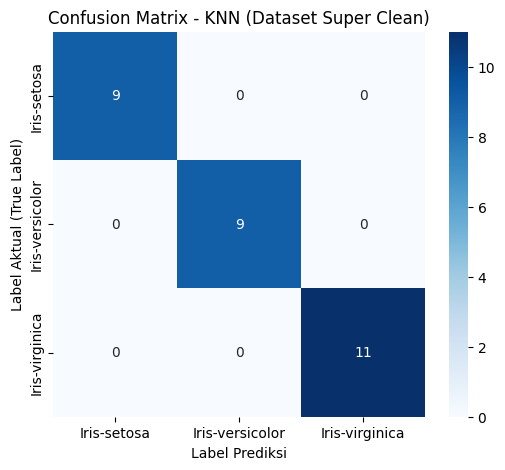

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. INISIALISASI MODEL
# Kita gunakan hyperparameter terbaik hasil Optuna sebelumnya
knn_model = KNeighborsClassifier(
    n_neighbors=20, 
    weights='uniform', 
    metric='euclidean'
)

# 2. TRAINING MODEL
print("Sedang melatih model...")
knn_model.fit(X_train, y_train)

# 3. MELAKUKAN PREDIKSI
y_pred = knn_model.predict(X_test)

# 4. EVALUASI AKURASI & REPORT
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model KNN Saat Ini: {akurasi * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# 5. VISUALISASI CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title("Confusion Matrix - KNN (Dataset Super Clean)")
plt.xlabel("Label Prediksi")
plt.ylabel("Label Aktual (True Label)")
plt.show()

# Eval

✅ Akurasi Testing : 100.00%

📊 CLASSIFICATION REPORT:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         9
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        29
      macro avg       1.00      1.00      1.00        29
   weighted avg       1.00      1.00      1.00        29

-------------------------------------------------------

🔄 CROSS-VALIDATION (5-Fold):
Skor tiap lipatan : [0.931  1.     0.8966 0.8966 1.    ]
Rata-rata Akurasi : 94.48% (± 4.68%)
-------------------------------------------------------


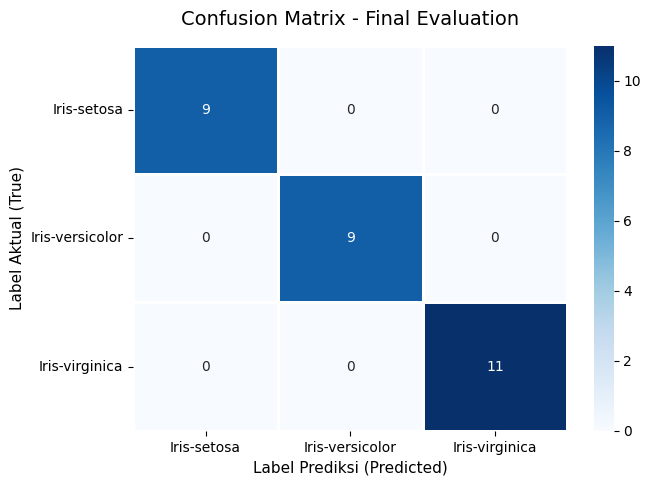

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

# 1. LAKUKAN PREDIKSI (Berdasarkan model knn_model dari cell sebelumnya)
y_pred = knn_model.predict(X_test)

# 2. AKURASI DASAR
akurasi = accuracy_score(y_test, y_pred)
print(f"✅ Akurasi Testing : {akurasi * 100:.2f}%\n")

# 3. CLASSIFICATION REPORT (Melihat detail tiap kelas)
print("📊 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))
print("-" * 55 + "\n")

# 4. CROSS VALIDATION (Evaluasi Tingkat Lanjut)
# Memecah seluruh data (145 baris) menjadi 5 lipatan untuk diuji secara bergantian
cv_scores = cross_val_score(knn_model, X_scaled, y, cv=5)
print("🔄 CROSS-VALIDATION (5-Fold):")
print(f"Skor tiap lipatan : {np.round(cv_scores, 4)}")
print(f"Rata-rata Akurasi : {cv_scores.mean() * 100:.2f}% (± {cv_scores.std() * 100:.2f}%)")
print("-" * 55)

# 5. VISUALISASI CONFUSION MATRIX YANG LEBIH CANTIK
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    linewidths=1,       # Menambahkan garis batas antar kotak
    linecolor='white'
)
plt.title("Confusion Matrix - Final Evaluation", fontsize=14, pad=15)
plt.xlabel("Label Prediksi (Predicted)", fontsize=11)
plt.ylabel("Label Aktual (True)", fontsize=11)
# Menyempurnakan rotasi label agar mudah dibaca
plt.xticks(rotation=0) 
plt.yticks(rotation=0)
plt.show()